In [ ]:
with open('raw_deepseek_chinese_translations.txt', 'r', encoding='utf-8') as trans_file, \
  open('/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/sentences0.txt', 'r', encoding='utf-8') as s0_file, \
  open('/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/sentences1.txt', 'r', encoding='utf-8') as s1_file, \
  open('aligned_filtered_translations.txt', 'w', encoding='utf-8') as out_file:

    # Build a mapping from English sentence to translation line
    trans_map = {}
    for trans_line in trans_file:
        eng = trans_line.split('\t')[0].strip()
        trans_map[eng] = trans_line

    s0_file.seek(0)
    s1_file.seek(0)

    for idx, (s0_line, s1_line) in enumerate(zip(s0_file, s1_file)):
        s0_eng = s0_line.strip()
        s1_eng = s1_line.strip()
        # Write the translation if present, in the same order as s0/s1
        if s0_eng in trans_map:
            out_file.write(trans_map[s0_eng])
        elif s1_eng in trans_map:
            out_file.write(trans_map[s1_eng])
        else:
            print(idx, s0_eng, s1_eng)

In [3]:
with open('aligned_filtered_translations.txt', 'r', encoding='utf-8') as aligned_file, \
     open('sentences0.txt', 'w', encoding='utf-8') as eng_file, \
     open('sentences1.txt', 'w', encoding='utf-8') as trans_file:

    for line in aligned_file:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            eng_file.write(parts[0] + '\n')
            trans_file.write(parts[1] + '\n')
        else:
            print("Skipping malformed line:", line)
            print('!!!')


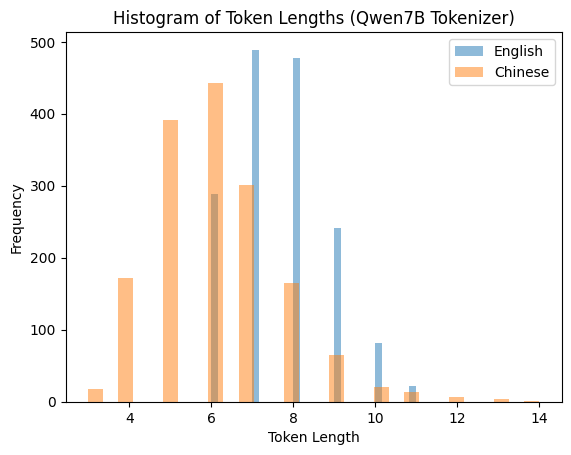

In [4]:
with open('sentences0.txt', 'r', encoding='utf-8') as f0, open('sentences1.txt', 'r', encoding='utf-8') as f1:
  sentences0 = [line.strip() for line in f0]
  sentences1 = [line.strip() for line in f1]

token_lengths0 = [len(tokenizer.encode(s, add_special_tokens=False)) for s in sentences0]
token_lengths1 = [len(tokenizer.encode(s, add_special_tokens=False)) for s in sentences1]

plt.hist(token_lengths0, bins=30, alpha=0.5, label='English')
plt.hist(token_lengths1, bins=30, alpha=0.5, label='Chinese')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.title('Histogram of Token Lengths (Qwen7B Tokenizer)')
plt.legend()
plt.show()

In [5]:
token_lengths1

[6,
 8,
 6,
 11,
 6,
 10,
 6,
 7,
 7,
 8,
 6,
 7,
 7,
 8,
 9,
 7,
 5,
 8,
 6,
 6,
 9,
 7,
 5,
 7,
 6,
 9,
 11,
 6,
 7,
 9,
 7,
 6,
 10,
 5,
 8,
 7,
 7,
 6,
 6,
 5,
 8,
 8,
 6,
 9,
 8,
 7,
 8,
 5,
 3,
 5,
 7,
 5,
 6,
 7,
 6,
 6,
 6,
 6,
 8,
 7,
 5,
 6,
 6,
 5,
 7,
 7,
 8,
 9,
 5,
 5,
 6,
 5,
 5,
 6,
 11,
 5,
 7,
 3,
 9,
 7,
 5,
 6,
 10,
 6,
 6,
 7,
 6,
 8,
 6,
 7,
 7,
 8,
 7,
 4,
 8,
 8,
 5,
 7,
 5,
 5,
 6,
 4,
 5,
 6,
 7,
 7,
 5,
 6,
 7,
 8,
 6,
 8,
 6,
 7,
 7,
 7,
 9,
 7,
 6,
 6,
 6,
 6,
 8,
 4,
 7,
 6,
 11,
 5,
 5,
 8,
 7,
 7,
 7,
 9,
 6,
 10,
 7,
 6,
 5,
 5,
 12,
 9,
 6,
 5,
 5,
 8,
 4,
 10,
 4,
 5,
 6,
 4,
 5,
 5,
 6,
 5,
 7,
 6,
 8,
 9,
 6,
 6,
 7,
 5,
 7,
 6,
 5,
 7,
 13,
 4,
 7,
 4,
 4,
 8,
 7,
 8,
 6,
 6,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 4,
 6,
 7,
 5,
 6,
 8,
 6,
 6,
 4,
 6,
 4,
 5,
 5,
 8,
 5,
 6,
 7,
 5,
 5,
 6,
 5,
 7,
 7,
 6,
 7,
 7,
 6,
 6,
 7,
 7,
 6,
 3,
 7,
 6,
 6,
 13,
 6,
 4,
 8,
 5,
 5,
 7,
 5,
 4,
 6,
 4,
 8,
 5,
 6,
 4,
 7,
 6,
 5,
 8,
 4,
 7,
 5,
 5,
 6,
 6,
